<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/LoRA_and_QLoRA_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue"><b>Code Demo for LoRa and QLoRA </b></font>

## <font color="blue"><b>1. Objective of this Demo ? </b></font>

Session Objectives- By the end of this code demo, participants will be able to:

1. Understand the idea of LoRA.

2. Difference between LoRA and Q-LoRA.

3. From scratch Implementation of LoRA.

4. Real time performance gap between the above techniques.

**What does FineTuning do ?** It allows the model to adapt to specific domains without costly pretraining, yet updating all layers can still be computationally expensive, especially for larger models.

LoRA offers a more efficient alternative to regular finetuning.

## <font color="blue"><b>2. Install Libraries </b></font>

We deliberately keep the dependency list short. `transformers` + `datasets` give us the model
and the data; `bitsandbytes` gives us the *production* NF4 kernels and the paged optimizer.

Note what is **not** in this list: `peft`. In real projects you would `pip install peft`. Here we implement LoRA ourselves, because the point of the session is to see what those three lines do.

In [ ]:
%pip install -q -U "transformers>=4.44.0" "datasets>=2.19.0" "accelerate>=0.33.0" "bitsandbytes>=0.43.0" "peft"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 21.1 MB/s eta 0:00:00


## <font color="blue"><b>3. Libraries Import and small utility functions </b></font>

In [ ]:
import gc, json, math, os, random, time, warnings, re
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint


## Transformer libraries:
from transformers import (AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
                          get_linear_schedule_with_warmup)

## Libraires for plotting
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

warnings.filterwarnings("ignore")


DEVICE, GB = "cuda" if torch.cuda.is_available() else "cpu", 1024 ** 3


MODEL_ID   = "EleutherAI/pythia-410m"     # Apache 2.0 - small enough that FULL fine-tuning
DATASET_ID = "b-mc2/sql-create-context"   # also fits on a T4, so the comparison has no gaps

SEED, QUICK_MODE = 42, False
TRAIN_STEPS = 70 if QUICK_MODE else 200

COLORS = {"Full fine-tuning": "#c0392b", "LoRA": "#2980b9", "QLoRA": "#27ae60"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10})

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def peak_gb():
    return torch.cuda.max_memory_allocated() / GB if torch.cuda.is_available() else 0.0


def reset_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()



set_seed()
def human(n):
    for u, d in (("B", 1e9), ("M", 1e6), ("K", 1e3)): #to print in Million(M), Billion(B), Thousand(K) # 9e8 prints as 900.00M
        if n >= d:
            return f"{n/d:.2f}{u}"
    return str(int(n))


set_seed()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) \
            else torch.float16
print(f"device: {DEVICE} | {torch.cuda.get_device_name(0) if DEVICE=='cuda' else ''}")
print(f"AMP dtype: {AMP_DTYPE} | model: {MODEL_ID} | steps: {TRAIN_STEPS}")

device: cuda | Tesla T4
AMP dtype: torch.bfloat16 | model: EleutherAI/pythia-410m | steps: 200


# <font color="blue"><b>Section-1: The problem: what full fine-tuning costs?</b></font>

Before any code, the number that motivates the entire session.

1. To update a parameter with Adam you must hold, *per parameter*: the weight itself, its gradient, and the optimizer's two moment estimates.

2. In the mixed-precision recipe; is 2 + 2 + 8 = **12 bytes for every single parameter you want to train**.


<p align="center">
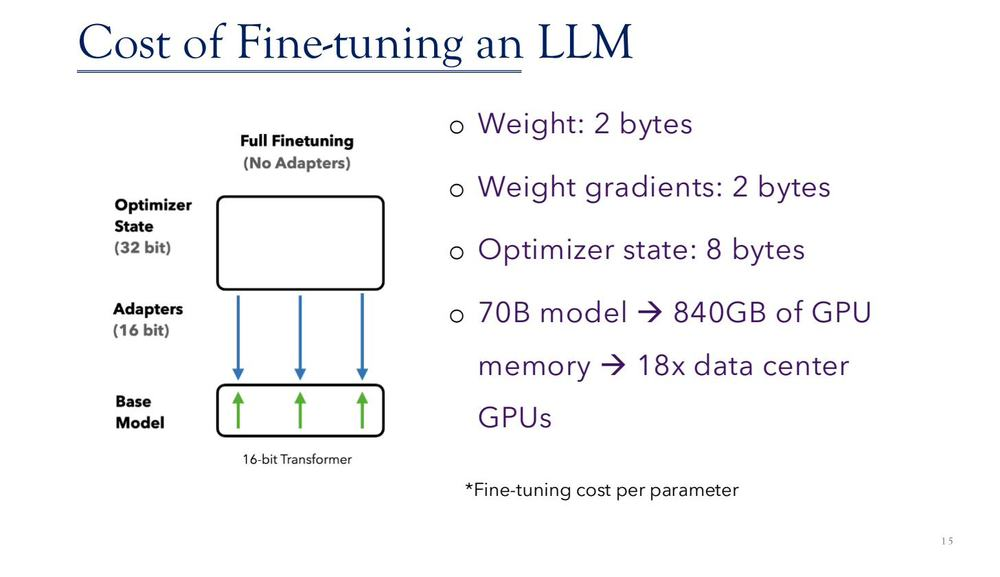<br>


<p align="center">
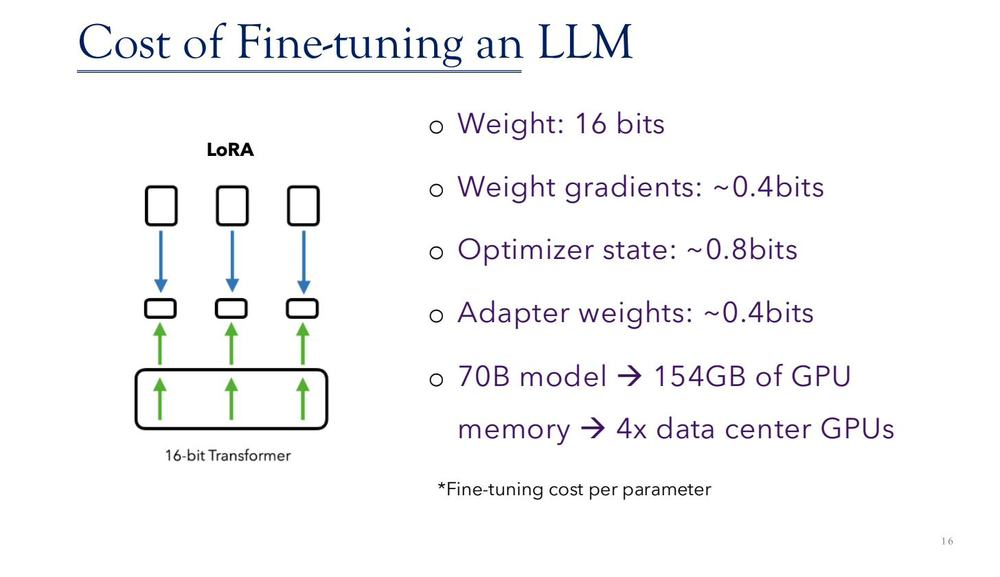<br>

## 1.1 Memory Calculation
- Let us write the accounting down as a function and check it reproduces every number.

In [ ]:
# Per-parameter cost of each recipe, in BITS as you can see in above slides.

RECIPES = {
    "Full fine-tuning": dict(weights=16, gradients=16, optimizer=64, adapters=0),
    "LoRA":             dict(weights=16, gradients=0.4, optimizer=0.8, adapters=0.4),
    "QLoRA":            dict(weights=4,  gradients=0.4, optimizer=0.4, adapters=0.4),
}


DATACENTER_GPU_GB = 48   # the deck's "data centre GPU"; [You can change the number here to see how it, depending upon the size of GPU you have]- H100(80 GB)

def bits_per_parameter(recipe: Dict[str, float]) -> float:
    """Total resident bits for every parameter of the base model."""
    return float(sum(recipe.values()))


def memory_footprint_gb(n_params: float, recipe: Dict[str, float]) -> float:
    """GPU memory (in decimal GB, as the deck quotes) to fine-tune a model of n_params."""
    return n_params * bits_per_parameter(recipe) / 8 / 1e9


def gpus_needed(n_params: float, recipe: Dict[str, float],
                gpu_gb: int = DATACENTER_GPU_GB) -> int:
    return math.ceil(memory_footprint_gb(n_params, recipe) / gpu_gb)


rows = []
for name, rec in RECIPES.items():
    rows.append({
        "method": name,
        "bits/param": bits_per_parameter(rec),
        "70B footprint (GB)": round(memory_footprint_gb(70e9, rec), 1),
        f"{DATACENTER_GPU_GB}GB GPUs": gpus_needed(70e9, rec),
        "vs full FT": f"{memory_footprint_gb(70e9, RECIPES['Full fine-tuning']) / memory_footprint_gb(70e9, rec):.1f}x smaller",
    })
display(pd.DataFrame(rows).set_index("method"))


,bits/param,70B footprint (GB),48GB GPUs,vs full FT
method,,,,
Full fine-tuning,96.0,840.0,18,1.0x smaller
LoRA,17.6,154.0,4,5.5x smaller
QLoRA,5.2,45.5,1,18.5x smaller


# <font color="blue"><b>Section-2: Component 1 — LoRA from scratch </b></font>


### The idea in one picture and one equation

In [ ]:
from IPython.display import Image, display
import os

image_path = "Screenshot 2026-08-01 at 00.05.06.png"
if os.path.exists(image_path):
    display(Image(image_path, width=900))
else:
    print(f"[Image placeholder: {image_path} not found. This image illustrates the LoRA architecture concept: W = W0 + B @ A]")

[Image placeholder: Screenshot 2026-08-01 at 00.05.06.png not found. This image illustrates the LoRA architecture concept: W = W0 + B @ A]


## <font color="green"><b>Parameters Update </b></font>

Full fine-tuning learns an unrestricted update to every weight matrix:

$$W' = W_0 + \Delta W, \qquad W_0,\ \Delta W \in \mathbb{R}^{d \times k}$$

LoRA's claim (Hu et al., 2022) is that $\Delta W$, *the update*, has low intrinsic rank — so we
never need to represent it densely. Factor it:

$$\Delta W = B A, \qquad B \in \mathbb{R}^{d \times r},\quad A \in \mathbb{R}^{r \times k},
\quad r \ll \min(d,k)$$

and the layer's forward pass becomes

$$h = W_0 x \;+\; \frac{\alpha}{r} B A x$$

$W_0$ is **frozen**. Only $A$ and $B$ receive gradients, so instead of $d \times k$ trainable
parameters we have $r\,(d + k)$. For a 1024×1024 attention projection at $r=16$ that is
32,768 instead of 1,048,576 — a **32× reduction**, on that layer.

## Two details that decide whether training works at all

In [ ]:
from IPython.display import Image, display
import os

image_path = "Screenshot 2026-08-01 at 00.04.54.png"
if os.path.exists(image_path):
    display(Image(image_path, width=900))
else:
    print(f"[Image placeholder: {image_path} not found. This image illustrates why adaptation begins with zero initialization of the B matrix]")

[Image placeholder: Screenshot 2026-08-01 at 00.04.54.png not found. This image illustrates why adaptation begins with zero initialization of the B matrix]


**Initialization.** One of the two factors must start at zero, so that $BA = 0$ and the
adapted model is *bit-identical to the pre-trained model at step 0*. If both were random, you
would corrupt a carefully pre-trained network before the first gradient arrives. We follow the
original paper QLoRA figure: the down-projection is Gaussian and
the up-projection is zero. The property that matters is only that the product starts at zero.


## <font color="green"><b>LoRA Implementation </b></font>

## Note the design:

**Scaling.** The magnitude of $BA$ grows with $r$, so a learning rate tuned at $r=8$ would be
too aggressive at $r=64$. Dividing by $r$ normalizes that away; $\alpha$ then acts as a single
"LoRA strength" knob you tune once. In code the whole thing is one float: `scaling = alpha / r`.


`LoRALinear` **wraps** an existing layer rather than replacing it. That single
decision is what lets the same class work for an ordinary `nn.Linear` (LoRA) *and* for a
`bitsandbytes.nn.Linear4bit` (QLoRA) without changing a line.

In [ ]:
class LoRALinear(nn.Module):
    """A frozen linear layer plus a trainable low-rank update.

        h = W0 @ x  +  (alpha / r) * B @ (A @ x)

    Args:
        base_layer: any module with .in_features/.out_features and a linear forward.
                    Works for nn.Linear AND for bitsandbytes Linear4bit -> this is the
                    single line of reuse that turns LoRA into QLoRA.
        r:          the rank. Trainable parameter count is r * (d_in + d_out).
        alpha:      scaling numerator. Effective scale is alpha / r (deck slide 9).
        dropout:    dropout on the LoRA branch input only; the frozen path is untouched.
    """

    def __init__(self, base_layer: nn.Module, r: int = 16, alpha: int = 32,
                 dropout: float = 0.0):
        super().__init__()
        if r <= 0:
            raise ValueError("rank r must be positive")
        self.base_layer = base_layer                # base_layers = All layers of the pretrained (base) model.
        for p in self.base_layer.parameters():
            p.requires_grad_(False)                 # W0 is frozen. This is the whole point.

        d_in, d_out = base_layer.in_features, base_layer.out_features
        self.r, self.alpha = r, alpha
        self.scaling = alpha / r                    # alpha / r, computed once

        # Adapters live wherever the base layer lives, and always in FP32: they are the
        # only weights an optimizer touches, and FP32 updates are what keeps that stable.
        device = next(base_layer.parameters()).device

        # A: d_in -> r   (the "down" projection, called A )
        # B: r -> d_out  (the "up"   projection, called B )
        self.lora_A = nn.Linear(d_in, r, bias=False, device=device, dtype=torch.float32)
        self.lora_B = nn.Linear(r, d_out, bias=False, device=device, dtype=torch.float32)

        # Near-zero initialization: B = 0 makes BA = 0, so the wrapped model starts out


        # numerically identical to the pre-trained one.
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base_layer(x)                            # frozen path
        h = self.lora_A(self.lora_dropout(x.to(self.lora_A.weight.dtype)))
        return base_out + self.scaling * self.lora_B(h).to(base_out.dtype)

    def extra_repr(self) -> str:
        return f"r={self.r}, alpha={self.alpha}, scaling={self.scaling:g}"



@torch.no_grad()
def merge_lora_(layer: LoRALinear) -> nn.Module:
    """Fold the adapter back into W0:  W0 <- W0 + (alpha/r) * B @ A.

    After merging, inference costs exactly what the original model cost - LoRA adds
    *zero* latency in deployment. Only valid for an un-quantized base layer; for a 4-bit
    base you must dequantize first (or simply keep the adapter separate, which is what
    people do in practice because it lets one base model serve many adapters).
    """
    delta = layer.scaling * (layer.lora_B.weight @ layer.lora_A.weight)
    layer.base_layer.weight += delta.to(layer.base_layer.weight.dtype)
    return layer.base_layer

`base_layer` can be any linear layer, and we never inspect what it is. Pass an ordinary `nn.Linear` and this is `LoRA`. Pass a `bitsandbytes.nn.Linear4bit` — which is what `BitsAndBytesConfig` turns every linear layer into at load time — and the exact same class becomes `QLoRA`.

That is the entire relationship between the two halves of this demo: the config decides how the frozen weights are stored, this class decides what gets trained.

## Finding the layers, and printing which ones got adapted

The QLoRA paper's recommendation is to adapt **every** linear layer in the transformer blocks,
not just the attention projections — it costs little and consistently helps. So instead of
hard-coding module names per architecture (which differ between GPT-NeoX, Llama, Mistral, …),
we discover them.

In [ ]:
def find_lora_targets(model, exclude=("lm_head", "embed_out", "score")) -> List[str]:
    """Every linear layer worth adapting. Catches nn.Linear AND bitsandbytes Linear4bit."""
    return [n for n, m in model.named_modules()
            if (isinstance(m, nn.Linear) or m.__class__.__name__ in ("Linear4bit", "Linear8bitLt"))
            and not any(t in n for t in exclude)]


def inject_lora(model, names, r, alpha, dropout=0.05):
    for name in names:
        parent_name, _, child = name.rpartition(".")
        parent = model.get_submodule(parent_name) if parent_name else model
        setattr(parent, child, LoRALinear(getattr(parent, child), r, alpha, dropout))
    return model


def mark_only_lora_as_trainable(model):
    for n, p in model.named_parameters():
        p.requires_grad_("lora_" in n)


def logical_numel(p) -> int:
    """4-bit params pack 2 weights per byte, so p.numel() would under-count by 2x."""
    if p.__class__.__name__ == "Params4bit":
        shape = getattr(getattr(p, "quant_state", None), "shape", None)
        return int(np.prod(tuple(shape))) if shape is not None else p.numel() * 2
    return p.numel()


def count_parameters(model) -> Dict[str, float]:
    tr = sum(logical_numel(p) for p in model.parameters() if p.requires_grad)
    tot = sum(logical_numel(p) for p in model.parameters())
    return {"trainable": tr, "total": tot, "trainable_pct": 100 * tr / max(tot, 1)}


def show_lora_targets(model, names, r) -> pd.DataFrame:
    """Print EXACTLY which layers of this model receive an adapter, and what they cost."""
    groups = {}
    for n in names:
        m = model.get_submodule(n)
        # m = getattr(m, "base_layer", m)
        key = re.sub(r"\.\d+\.", ".*.", n)                # collapse the layer index
        g = groups.setdefault(key, {"layer pattern": key, "count": 0,
                                    "in": m.in_features, "out": m.out_features})
        g["count"] += 1
    df = pd.DataFrame(groups.values())
    df["dense params (each)"] = df["in"] * df["out"]
    df["LoRA params (each)"] = r * (df["in"] + df["out"])
    df["LoRA params (total)"] = df["count"] * df["LoRA params (each)"]
    df["saving"] = (df["dense params (each)"] / df["LoRA params (each)"]).map("{:.0f}x".format)

    print(f"LoRA (r={r}) applied to {len(names)} layers, in {len(df)} distinct positions:\n")
    display(df.style.format({"dense params (each)": "{:,.0f}", "LoRA params (each)": "{:,.0f}",
                             "LoRA params (total)": "{:,.0f}"}).hide(axis="index"))
    print("first three adapted modules :", names[:3])
    print("last  three adapted modules :", names[-3:])
    skipped = [n for n, m in model.named_modules()
               if isinstance(m, (nn.Linear, nn.Embedding, nn.LayerNorm)) and n not in names]
    print(f"\nNOT adapted ({len(skipped)} modules): embeddings, the output head and every "
          f"LayerNorm, e.g. {skipped[:4]}")
    return df

# <font color="blue"><b>Section-3. Global Configuration </b></font>



One dataclass drives every experiment. Change values here rather than editing code below.

**About `MODEL_ID`.** The default is `EleutherAI/pythia-410m` (Apache 2.0), chosen for one
specific reason: it is small enough that *all three* methods &mdash; including full fine-tuning &mdash; actually complete on a free T4, so the comparison table has no holes in it.

## Try for Yourself

- Flip `MODEL_ID` to `TinyLlama/TinyLlama-1.1B-Chat-v1.0` and the picture changes in the most instructive way possible: full fine-tuning runs out of memory, while LoRA and QLoRA carry on untroubled.
- That failure is itself a result.

In [ ]:
# ----------------------------------------------------------------------------
# Change things HERE, not in the code below.
# ----------------------------------------------------------------------------
@dataclass
class RunConfig:
    name: str
    mode: str                              # "full" | "lora" | "qlora"
    model_id: str = MODEL_ID
    lora_r: int = 16
    lora_alpha: int = 32                   # effective scale = alpha / r
    lora_dropout: float = 0.05
    lr: float = 2e-4
    max_steps: int = TRAIN_STEPS
    batch_size: int = 4
    grad_accum: int = 2                    # effective batch = 8
    max_len: int = 256
    warmup_steps: int = 10
    grad_clip: float = 1.0
    gradient_checkpointing: bool = True
    optimizer: str = "adamw"               # "adamw" | "paged_adamw_8bit"
    seed: int = SEED


def repair_lm_head(model, model_id=MODEL_ID):
    """Recent transformers renamed GPTNeoX's `embed_out` to `lm_head` but does not always
    remap the checkpoint, leaving the output head randomly initialized. Copy it back."""
    head = getattr(model, "lm_head", None) or getattr(model, "embed_out", None)
    if head is None:
        return model
    if head.weight.__class__.__name__ == "Params4bit":
        print("lm_head is quantized - skipping repair (unexpected; check your bnb config)")
        return model

    from huggingface_hub import hf_hub_download
    try:
        from safetensors.torch import load_file
        sd = load_file(hf_hub_download(model_id, "model.safetensors"))
    except Exception:
        sd = torch.load(hf_hub_download(model_id, "pytorch_model.bin"), map_location="cpu")

    key = "embed_out.weight" if "embed_out.weight" in sd else "lm_head.weight"
    head.weight.data.copy_(sd[key].to(device=head.weight.device, dtype=head.weight.dtype))
    print(f"  repaired output head from '{key}'")
    return model


def load_base_model(cfg):
    """Full fine-tuning keeps FP32 master weights; LoRA freezes the base so FP16 is enough."""
    if cfg.mode == "qlora":
        model = AutoModelForCausalLM.from_pretrained(
            cfg.model_id, quantization_config=QLORA_CONFIG, device_map={"": 0})
    else:
        dtype = torch.float32 if cfg.mode == "full" else torch.float16
        model = AutoModelForCausalLM.from_pretrained(cfg.model_id, torch_dtype=dtype).to(DEVICE)
        if next(model.parameters()).dtype != dtype:
            model = model.to(dtype)

    model = repair_lm_head(model, cfg.model_id)     # <-- the fix, applied in all three modes
    model.config.use_cache = False                  # incompatible with gradient checkpointing
    return model


def prepare_for_training(model, cfg):
    """LayerNorms in FP32 (that is where FP16 overflows), plus gradient checkpointing."""
    if cfg.mode in ("lora", "qlora"):
        for name, mod in model.named_modules():
            leaf = not any(True for _ in mod.children())
            if leaf and (isinstance(mod, nn.LayerNorm) or "norm" in name.lower()):
                mod.to(torch.float32)
    if cfg.gradient_checkpointing:
        if hasattr(model, "enable_input_require_grads"):
            model.enable_input_require_grads()
        try:
            model.gradient_checkpointing_enable(
                gradient_checkpointing_kwargs={"use_reentrant": False})
        except TypeError:
            model.gradient_checkpointing_enable()
    return model


def build_optimizer(model, cfg):
    params = [p for p in model.parameters() if p.requires_grad]
    if cfg.optimizer == "paged_adamw_8bit":
        return bnb.optim.PagedAdamW8bit(params, lr=cfg.lr)      #
    return torch.optim.AdamW(params, lr=cfg.lr)


def build_model(cfg, verbose=True):
    """THE ASSEMBLY POINT.

        full  : every parameter trainable, FP32 weights            (the 840 GB recipe)
        lora  : FP16 frozen base + trainable adapters              (the 154 GB recipe)
        qlora : NF4 double-quantized base + trainable adapters      (the  46 GB recipe)
    """
    set_seed(cfg.seed); free_memory(); reset_peak()
    model = load_base_model(cfg)
    mem_load = torch.cuda.memory_allocated() / GB

    if cfg.mode in ("lora", "qlora"):
        targets = find_lora_targets(model)
        inject_lora(model, targets, cfg.lora_r, cfg.lora_alpha, cfg.lora_dropout)
        mark_only_lora_as_trainable(model)
        if verbose:
            show_lora_targets(model, targets, cfg.lora_r)
    else:
        for p in model.parameters():
            p.requires_grad_(True)

    model = prepare_for_training(model, cfg)
    stats = count_parameters(model)
    stats["mem_after_load_gb"] = mem_load
    # print(f"\n[{cfg.name}] trainable {human(stats['trainable'])} / {human(stats['total'])} "
    #       f"({stats['trainable_pct']:.2f} %) | model on GPU {mem_load:.3f} GB")
    return model, stats


def load_tokenizer(model_id=MODEL_ID):
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    return tok


tokenizer = load_tokenizer()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

### Prameters it adapts

In [ ]:
_probe = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
_targets = find_lora_targets(_probe)
_ = show_lora_targets(_probe, _targets, r=16)
del _probe; free_memory()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  911MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

LoRA (r=16) applied to 96 layers, in 4 distinct positions:



layer pattern,count,in,out,dense params (each),LoRA params (each),LoRA params (total),saving
gpt_neox.layers.*.attention.query_key_value,24,1024,3072,"3,145,728","65,536","1,572,864",48x
gpt_neox.layers.*.attention.dense,24,1024,1024,"1,048,576","32,768","786,432",32x
gpt_neox.layers.*.mlp.dense_h_to_4h,24,1024,4096,"4,194,304","81,920","1,966,080",51x
gpt_neox.layers.*.mlp.dense_4h_to_h,24,4096,1024,"4,194,304","81,920","1,966,080",51x


first three adapted modules : ['gpt_neox.layers.0.attention.query_key_value', 'gpt_neox.layers.0.attention.dense', 'gpt_neox.layers.0.mlp.dense_h_to_4h']
last  three adapted modules : ['gpt_neox.layers.23.attention.dense', 'gpt_neox.layers.23.mlp.dense_h_to_4h', 'gpt_neox.layers.23.mlp.dense_4h_to_h']

NOT adapted (51 modules): embeddings, the output head and every LayerNorm, e.g. ['gpt_neox.embed_in', 'gpt_neox.layers.0.input_layernorm', 'gpt_neox.layers.0.post_attention_layernorm', 'gpt_neox.layers.1.input_layernorm']


## How much do we actually save, as a function of rank?

Slide 13 makes the theoretical point: as $r \to \text{rank}(W_0)$, LoRA converges to full
fine-tuning; for small $r$ it is a cheap approximation that is still expressive. Here is the
cost side of that trade-off, for a transformer the size of our default model.

In [ ]:
from IPython.display import Image, display
import os

image_path = "Screenshot 2026-08-01 at 00.39.09.png"
if os.path.exists(image_path):
    display(Image(image_path, width=900))
else:
    print(f"[Image placeholder: {image_path} not found. This image shows the theoretical parameter cost curve compared to full fine-tuning]")

[Image placeholder: Screenshot 2026-08-01 at 00.39.09.png not found. This image shows the theoretical parameter cost curve compared to full fine-tuning]


Dense (full fine-tuning) parameters in the blocks: 301.99M


rank r,LoRA params,% of dense,compression
1,"393,216",0.13 %,768x
2,"786,432",0.26 %,384x
4,"1,572,864",0.52 %,192x
8,"3,145,728",1.04 %,96x
16,"6,291,456",2.08 %,48x
32,"12,582,912",4.17 %,24x
64,"25,165,824",8.33 %,12x
128,"50,331,648",16.67 %,6x
256,"100,663,296",33.33 %,3x
512,"201,326,592",66.67 %,2x


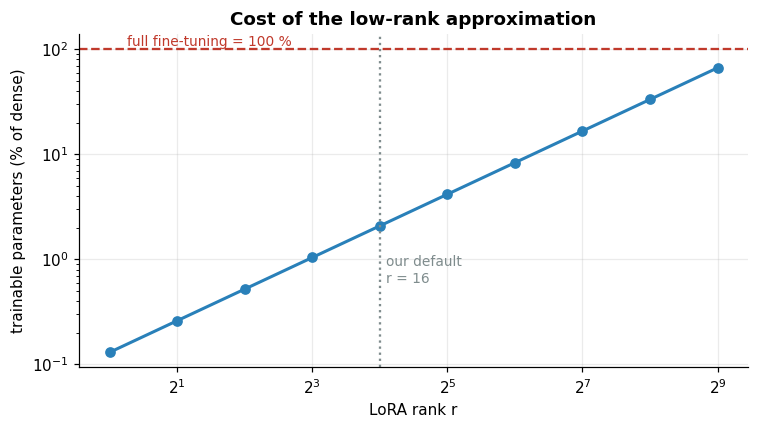

In [ ]:
def lora_parameter_budget(d_model=1024, n_layers=24, ffn_mult=4, ranks=(1, 2, 4, 8, 16, 32,
                                                                             64, 128, 256, 512)):
    """Trainable parameters vs rank for a GPT-style stack, adapting every linear layer."""
    # per layer: qkv (d -> 3d), out (d -> d), ffn up (d -> 4d), ffn down (4d -> d)
    shapes = [(d_model, 3 * d_model), (d_model, d_model),
              (d_model, ffn_mult * d_model), (ffn_mult * d_model, d_model)]
    dense = n_layers * sum(a * b for a, b in shapes)
    rows = []
    for r in ranks:
        lora = n_layers * sum(r * (a + b) for a, b in shapes)
        rows.append({"rank r": r, "LoRA params": lora,
                     "% of dense": 100 * lora / dense,
                     "compression": dense / lora})
    return pd.DataFrame(rows), dense


df_rank, dense_params = lora_parameter_budget()
print(f"Dense (full fine-tuning) parameters in the blocks: {human(dense_params)}")
display(df_rank.style.format({"LoRA params": "{:,.0f}", "% of dense": "{:.2f} %",
                              "compression": "{:.0f}x"}).hide(axis="index"))




# --------------------------------------------------------------------------------------------------
# ------------------------------------------------ Plots--------------------------------------------
# --------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_rank["rank r"], df_rank["% of dense"], "o-", color=COLORS["LoRA"], lw=2)
ax.axhline(100, ls="--", color=COLORS["Full fine-tuning"], lw=1.5)
ax.text(1.2, 108, "full fine-tuning = 100 %", color=COLORS["Full fine-tuning"], fontsize=9)
ax.axvline(16, ls=":", color="#7f8c8d")
ax.text(17, 0.6, "our default\nr = 16", fontsize=9, color="#7f8c8d")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("trainable parameters (% of dense)")
ax.set_title("Cost of the low-rank approximation")
plt.tight_layout(); plt.show()

# <font color="blue"><b>Section-4. Quantization — all of it through `BitsAndBytesConfig` </b></font>





<table><tr>
<td align="center">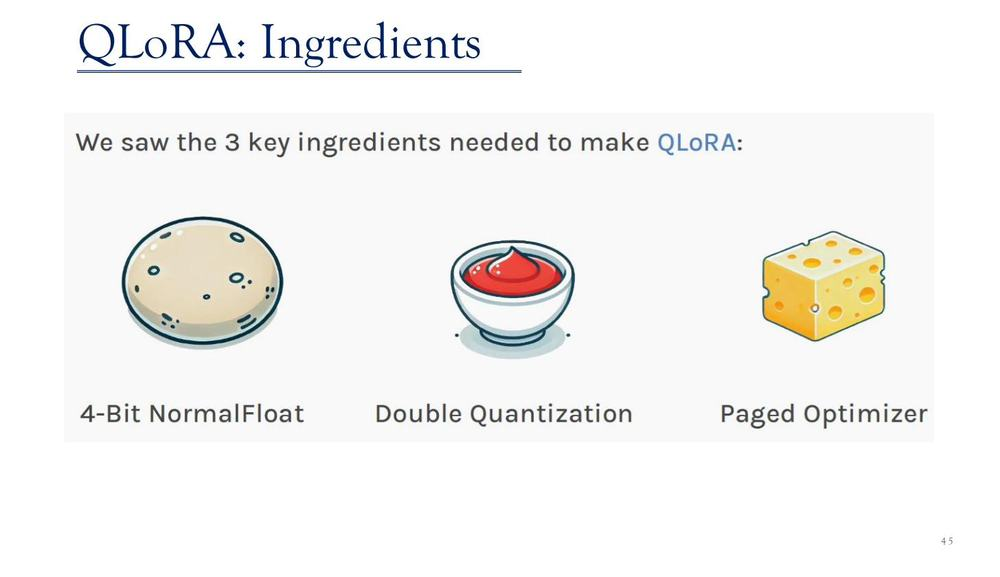<br><em>the three QLoRA ingredients</em></td>
<td align="center">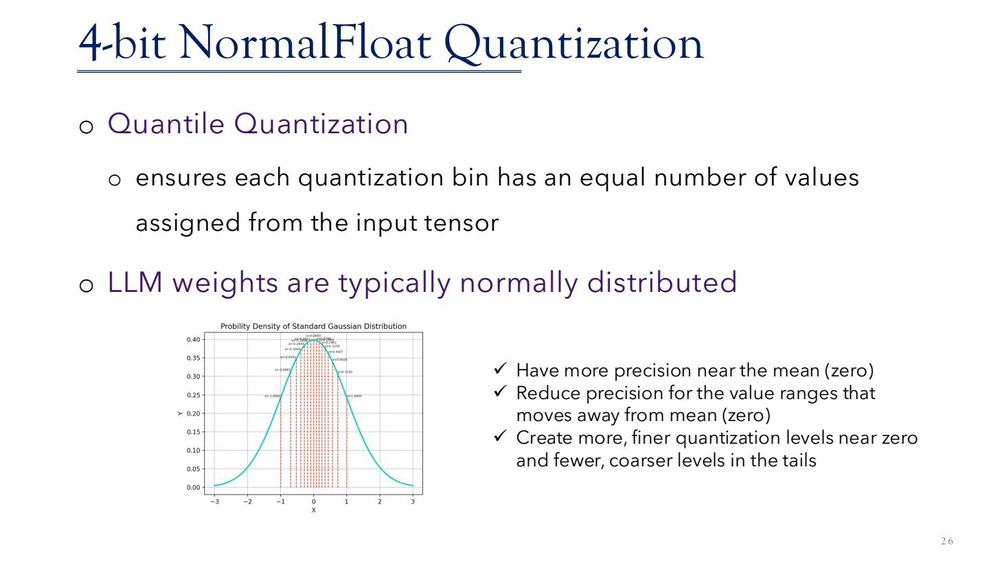<br><em>NF4: put the levels where the weights actually are</em></td>
</tr></table>


In [ ]:
from transformers import (AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
                          get_linear_schedule_with_warmup)
import bitsandbytes as bnb

QLORA_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,                     # store frozen weights in 4 bits
    bnb_4bit_quant_type="nf4",             # NormalFloat, not uniform INT4
    bnb_4bit_use_double_quant=True,        # quantize the block constants too
    bnb_4bit_compute_dtype=torch.float16,  # dequantize to this for the matmul
)
print(QLORA_CONFIG.to_json_string())

{
  "_load_in_4bit": true,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "load_in_4bit": true
}



### Load the same model twice and measure the difference

In [ ]:
def measure_quantization(model_id=MODEL_ID):
    """Load the same model twice - FP16 and NF4 - and compare size and weight error."""
    free_memory(); reset_peak()

    #
    fp16 = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(DEVICE)
    mem_fp16 = torch.cuda.memory_allocated() / GB
    ref = {n: p.detach().clone() for n, p in fp16.named_parameters()
           if "layers.5" in n and p.dim() == 2}            # keep one block for comparison
    del fp16; free_memory()

    #
    nf4 = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=QLORA_CONFIG,
                                               device_map={"": 0})
    mem_nf4 = torch.cuda.memory_allocated() / GB

    rows = []
    for name, original in ref.items():
        mod = nf4.get_submodule(name.rsplit(".weight", 1)[0])
        if mod.__class__.__name__ != "Linear4bit":
            continue
        restored = bnb.functional.dequantize_4bit(mod.weight.data, mod.weight.quant_state)
        err = (original.float() - restored.float().reshape(original.shape))
        rows.append({"weight matrix": name.replace("gpt_neox.layers.5.", ""),
                     "shape": tuple(original.shape),
                     "mean |error|": err.abs().mean().item(),
                     "relative error": (err.norm() / original.float().norm()).item()})

    print(f"FP16 model on GPU : {mem_fp16:.3f} GB")
    print(f"NF4  model on GPU : {mem_nf4:.3f} GB   ->  {mem_fp16/mem_nf4:.2f}x smaller\n")
    display(pd.DataFrame(rows).style.format({"mean |error|": "{:.5f}",
                                             "relative error": "{:.4f}"}).hide(axis="index"))
    del nf4; free_memory()
    return mem_fp16, mem_nf4


mem_fp16, mem_nf4 = measure_quantization(model_id=MODEL_ID)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

FP16 model on GPU : 0.755 GB
NF4  model on GPU : 0.372 GB   ->  2.03x smaller



weight matrix,shape,mean |error|,relative error
attention.query_key_value.weight,"(3072, 1024)",0.00185,0.0923
attention.dense.weight,"(1024, 1024)",0.00143,0.0919
mlp.dense_h_to_4h.weight,"(4096, 1024)",0.00172,0.0918
mlp.dense_4h_to_h.weight,"(1024, 4096)",0.00147,0.0929


the config knobs actually matter

# <font color="blue"><b>Section-5. DataSet and Setup </b></font>

**Task: text-to-SQL.** A 410M base model has seen SQL in pre-training but has no idea it is
supposed to answer with a query and nothing else. After a few hundred steps it does — a gap
that is large, automatic to measure, and visible by eye.

**Data:** [`b-mc2/sql-create-context`](https://huggingface.co/datasets/b-mc2/sql-create-context)
(CC BY-4.0) — 78,577 (question, `CREATE TABLE` schema, SQL) triples, built from WikiSQL
(BSD-3) and Spider (CC BY-SA-4.0). Short sequences, so it is fast on a T4.

We mask the prompt out of the loss (`labels = -100`) so the model is scored only on the SQL it
writes, and we measure held-out **loss**, **exact match** and **token-F1**.

Dataset, prompt template, tokenization with prompt masking

In [ ]:
from datasets import load_dataset

PROMPT = ("### Task\nWrite a SQL query that answers the question, using only the given schema.\n\n"
          "### Schema\n{context}\n\n### Question\n{question}\n\n### SQL\n")
IGNORE = -100


def build_prompt(ex):
    return PROMPT.format(context=ex["context"].strip(), question=ex["question"].strip())


raw = load_dataset(DATASET_ID, split="train").shuffle(seed=SEED)
train_raw = raw.select(range(1500 if QUICK_MODE else 4000))
eval_raw = raw.select(range(4000, 4200 if QUICK_MODE else 4400))


def encode(ex, tok, max_len):
    """Tokenize prompt + answer, masking the prompt tokens out of the loss."""
    p = tok(build_prompt(ex), add_special_tokens=False)["input_ids"]
    a = tok(ex["answer"].strip() + tok.eos_token, add_special_tokens=False)["input_ids"]
    a = a[:max_len - 8]
    p = p[-(max_len - len(a)):]                       # truncate the schema from the left
    return {"input_ids": p + a, "labels": [IGNORE] * len(p) + a}


class SQLData(torch.utils.data.Dataset):
    def __init__(self, hf, tok, max_len=256):
        self.rows = [encode(ex, tok, max_len) for ex in hf]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        return self.rows[i]


def collate(batch, pad_id):
    n = max(len(b["input_ids"]) for b in batch)
    pad = lambda seq, v: seq + [v] * (n - len(seq))
    return {"input_ids": torch.tensor([pad(b["input_ids"], pad_id) for b in batch]),
            "labels": torch.tensor([pad(b["labels"], IGNORE) for b in batch]),
            "attention_mask": torch.tensor([[1] * len(b["input_ids"]) + [0] * (n - len(b["input_ids"]))
                                            for b in batch])}


# One pair of loaders shared by every experiment: identical batches in identical order,
# so the only difference between runs is the method itself.
_fn = lambda b: collate(b, tokenizer.pad_token_id)
train_loader = torch.utils.data.DataLoader(SQLData(train_raw, tokenizer), batch_size=4,
                                           shuffle=True, collate_fn=_fn, drop_last=True)
eval_loader = torch.utils.data.DataLoader(SQLData(eval_raw, tokenizer), batch_size=4,
                                          collate_fn=_fn)

print(f"train {len(train_raw):,} | eval {len(eval_raw):,}\n" + "=" * 76)
print(build_prompt(train_raw[0]) + train_raw[0]["answer"])
print("=" * 76)
_b = next(iter(train_loader))
print(f"batch {tuple(_b['input_ids'].shape)} | tokens in loss "
      f"{(_b['labels'] != IGNORE).sum().item()} of {_b['labels'].numel()} (rest is prompt)")

README.md:   0%|          | 0.00/4.43k [00:00<?, ?B/s]

sql_create_context_v4.json: reconstructing file:   0%|          |  0.00B / 21.8MB            

sql_create_context_v4.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

train 4,000 | eval 400
### Task
Write a SQL query that answers the question, using only the given schema.

### Schema
CREATE TABLE table_name_50 (venue VARCHAR, away_team VARCHAR)

### Question
When Essendon played away; where did they play?

### SQL
SELECT venue FROM table_name_50 WHERE away_team = "essendon"
batch (4, 143) | tokens in loss 121 of 572 (rest is prompt)


## Evaluation Setup



In [ ]:
EVAL_BATCHES = 8 if QUICK_MODE else 24
N_GEN = 16 if QUICK_MODE else 40


def to_dev(b):
    return {k: v.to(DEVICE, non_blocking=True) for k, v in b.items()}


@torch.no_grad()
def evaluate_loss(model, loader, max_batches=EVAL_BATCHES):
    model.eval()
    out = []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        with torch.autocast("cuda", dtype=AMP_DTYPE):
            out.append(model(**to_dev(batch)).loss.item())
    return float(np.mean(out))


def clean_sql(t):
    for s in ("\n###", "\n\n", "\n"):
        t = t.split(s)[0] if s in t else t
    return t.strip().rstrip(";").strip()


def norm(s):
    return " ".join(s.lower().replace('"', "'").split())


def token_f1(pred, gold):
    p, g = norm(pred).split(), norm(gold).split()
    if not p or not g:
        return float(p == g)
    c = sum(min(p.count(t), g.count(t)) for t in set(p))
    return 0.0 if c == 0 else 2 * (c / len(p)) * (c / len(g)) / ((c / len(p)) + (c / len(g)))


@torch.no_grad()
def generate(model, tok, prompts, max_new_tokens=48, bs=8):
    """Greedy decoding. Temporarily re-enables the KV cache and disables checkpointing."""
    training, cache = model.training, model.config.use_cache
    ckpt = bool(getattr(model, "is_gradient_checkpointing", False))
    if ckpt:
        model.gradient_checkpointing_disable()
    model.config.use_cache = True; model.eval(); tok.padding_side = "left"
    preds = []
    for i in range(0, len(prompts), bs):
        enc = tok(prompts[i:i + bs], return_tensors="pt", padding=True,
                  truncation=True, max_length=384).to(DEVICE)
        with torch.autocast("cuda", dtype=AMP_DTYPE):
            out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                                 pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
        preds += tok.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    tok.padding_side = "right"; model.config.use_cache = cache
    if ckpt:
        model.gradient_checkpointing_enable()
    if training:
        model.train()
    return [clean_sql(p) for p in preds]


def evaluate_generation(model, tok, n=N_GEN):
    ex = [eval_raw[i] for i in range(n)]
    prompts, golds = [build_prompt(e) for e in ex], [e["answer"].strip() for e in ex]
    preds = generate(model, tok, prompts)
    return {"exact_match": float(np.mean([norm(p) == norm(g) for p, g in zip(preds, golds)])),
            "token_f1": float(np.mean([token_f1(p, g) for p, g in zip(preds, golds)])),
            "samples": list(zip(prompts[:3], golds[:3], preds[:3]))}

# <font color="blue"><b>Section-6. Training Pipeline </b></font>


In [ ]:
def make_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def train_model(model, cfg, loader):
    """Standard AMP + gradient-accumulation loop, instrumented for memory and time."""
    opt = build_optimizer(model, cfg)
    sched = get_linear_schedule_with_warmup(opt, cfg.warmup_steps, cfg.max_steps)
    scaler = make_scaler(AMP_DTYPE == torch.float16)
    params = [p for p in model.parameters() if p.requires_grad]
    model.train(); history, tokens, it = [], 0, iter(loader)
    torch.cuda.synchronize(); t0 = time.perf_counter()

    for step in range(1, cfg.max_steps + 1):
        opt.zero_grad(set_to_none=True); total = 0.0
        for _ in range(cfg.grad_accum):
            try:
                batch = next(it)
            except StopIteration:
                it = iter(loader); batch = next(it)
            batch = to_dev(batch); tokens += int(batch["attention_mask"].sum())
            with torch.autocast("cuda", dtype=AMP_DTYPE):
                loss = model(**batch).loss / cfg.grad_accum
            scaler.scale(loss).backward(); total += loss.item()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
        scaler.step(opt); scaler.update(); sched.step()
        history.append({"step": step, "loss": total})
        if step % max(cfg.max_steps // 8, 1) == 0 or step == 1:
            print(f"  step {step:>4d}/{cfg.max_steps}  loss {total:6.4f}  peak {peak_gb():5.2f} GB")

    torch.cuda.synchronize(); el = time.perf_counter() - t0
    return {"history": history, "train_seconds": el, "sec_per_step": el / cfg.max_steps,
            "tokens_per_sec": tokens / el}


def run_experiment(cfg, n_gen=N_GEN, eval_before=True, verbose=True):
    """Build -> evaluate -> train -> evaluate. Returns one results dict."""
    print("=" * 78 + f"\nEXPERIMENT: {cfg.name}  (mode={cfg.mode}, r={cfg.lora_r}, "
          f"lr={cfg.lr}, steps={cfg.max_steps})\n" + "=" * 78)
    free_memory(); reset_peak()
    res = {"config": asdict(cfg), "status": "ok"}
    model = None
    try:
        model, stats = build_model(cfg, verbose=verbose)
        res.update(stats)
        if eval_before:
            b = {"eval_loss": evaluate_loss(model, eval_loader)}
            b.update(evaluate_generation(model, tokenizer, n_gen))
            res["before"] = b
            print(f"  BEFORE  loss {b['eval_loss']:.4f} | EM {b['exact_match']:.3f} | "
                  f"F1 {b['token_f1']:.3f}")
        reset_peak()
        res.update(train_model(model, cfg, train_loader))
        res["peak_train_memory_gb"] = peak_gb()
        a = {"eval_loss": evaluate_loss(model, eval_loader)}
        a.update(evaluate_generation(model, tokenizer, n_gen))
        res["after"] = a
        print(f"  AFTER   loss {a['eval_loss']:.4f} | EM {a['exact_match']:.3f} | "
              f"F1 {a['token_f1']:.3f} | peak {res['peak_train_memory_gb']:.2f} GB "
              f"| {res['sec_per_step']:.2f} s/step")
    except torch.cuda.OutOfMemoryError as e:
        res["status"] = "OOM"
        print(f"\n*** {cfg.name} ran OUT OF MEMORY - which is exactly the failure mode "
              f"PEFT exists to prevent. Recorded as a result. ***")
    except Exception as e:
        res["status"] = f"error: {type(e).__name__}"
        print(f"\n*** {cfg.name} failed: {type(e).__name__}: {e} ***")
    finally:
        del model; free_memory()
    return res

# <font color="blue"><b>Section-7. The comparison: full fine-tuning vs LoRA vs QLoRA </b></font>


Same model, same data, same batches, same number of steps. Only the method changes.

The learning rates differ deliberately: full fine-tuning moves every weight and needs a small
LR (2e-5); LoRA-style methods move a small low-rank branch and want a larger one (2e-4). Using
one LR for both would be a rigged comparison.

*Roughly 4–6 minutes per run on a free T4.*

In [ ]:
assert torch.cuda.is_available(), "Runtime > Change runtime type > T4 GPU, then re-run."

EXPERIMENTS = [
    RunConfig(name="Full fine-tuning", mode="full",  lr=2e-5, optimizer="adamw"),
    RunConfig(name="LoRA",             mode="lora",  lr=2e-4, optimizer="adamw"),
    RunConfig(name="QLoRA",            mode="qlora", lr=2e-4, optimizer="paged_adamw_8bit"),
]

RESULTS, t0 = {}, time.perf_counter()
for cfg in EXPERIMENTS:
    RESULTS[cfg.name] = run_experiment(cfg, verbose=(cfg.mode == "qlora"))
print(f"\nALL DONE in {(time.perf_counter()-t0)/60:.1f} minutes")

EXPERIMENT: Full fine-tuning  (mode=full, r=16, lr=2e-05, steps=200)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  BEFORE  loss 1.0121 | EM 0.000 | F1 0.684
  step    1/200  loss 0.7570  peak  7.57 GB
  step   25/200  loss 0.3155  peak  7.57 GB
  step   50/200  loss 0.0924  peak  7.57 GB
  step   75/200  loss 0.1325  peak  7.57 GB
  step  100/200  loss 0.4951  peak  7.57 GB
  step  125/200  loss 0.0576  peak  7.57 GB
  step  150/200  loss 0.0325  peak  7.57 GB
  step  175/200  loss 0.0920  peak  7.57 GB
  step  200/200  loss 0.1462  peak  7.58 GB
  AFTER   loss 0.1680 | EM 0.550 | F1 0.919 | peak 7.58 GB | 1.32 s/step
EXPERIMENT: LoRA  (mode=lora, r=16, lr=0.0002, steps=200)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  BEFORE  loss 0.9764 | EM 0.000 | F1 0.699
  step    1/200  loss 0.7584  peak  1.24 GB
  step   25/200  loss 0.3335  peak  1.39 GB
  step   50/200  loss 0.0925  peak  1.39 GB
  step   75/200  loss 0.1499  peak  1.39 GB
  step  100/200  loss 0.4922  peak  1.39 GB
  step  125/200  loss 0.0661  peak  1.50 GB
  step  150/200  loss 0.0510  peak  1.50 GB
  step  175/200  loss 0.0604  peak  1.50 GB
  step  200/200  loss 0.1453  peak  1.50 GB
  AFTER   loss 0.1756 | EM 0.475 | F1 0.904 | peak 1.50 GB | 1.18 s/step
EXPERIMENT: QLoRA  (mode=qlora, r=16, lr=0.0002, steps=200)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'

*** QLoRA failed: AttributeError: 'LoRALinear' object has no attribute 'in_features' ***

ALL DONE in 9.7 minutes


In [ ]:
def results_table(results):
    rows = []
    for name, r in results.items():
        if r.get("status") != "ok":
            rows.append({"method": name, "status": r["status"]}); continue
        rows.append({"method": name, "status": "ok",
                     "trainable params": r["trainable"], "% trainable": r["trainable_pct"],
                     "model on GPU (GB)": r["mem_after_load_gb"],
                     "peak memory (GB)": r["peak_train_memory_gb"],
                     "sec / step": r["sec_per_step"],
                     "loss before": r["before"]["eval_loss"], "loss after": r["after"]["eval_loss"],
                     "exact match": r["after"]["exact_match"], "token F1": r["after"]["token_f1"]})
    df = pd.DataFrame(rows).set_index("method")
    fmt = {"trainable params": "{:,.0f}", "% trainable": "{:.2f} %", "model on GPU (GB)": "{:.3f}",
           "peak memory (GB)": "{:.2f}", "sec / step": "{:.2f}", "loss before": "{:.3f}",
           "loss after": "{:.3f}", "exact match": "{:.3f}", "token F1": "{:.3f}"}
    return df, {k: v for k, v in fmt.items() if k in df.columns}


df_res, _fmt = results_table(RESULTS)
display(df_res.style.format(_fmt, na_rep="-"))

,status,trainable params,% trainable,model on GPU (GB),peak memory (GB),sec / step,loss before,loss after,exact match,token F1
method,,,,,,,,,,
Full fine-tuning,ok,"405,334,016",100.00 %,1.510,7.58,1.32,1.012,0.168,0.550,0.919
LoRA,ok,"6,291,456",1.53 %,0.773,1.50,1.18,0.976,0.176,0.475,0.904
QLoRA,error: AttributeError,-,-,-,-,-,-,-,-,-


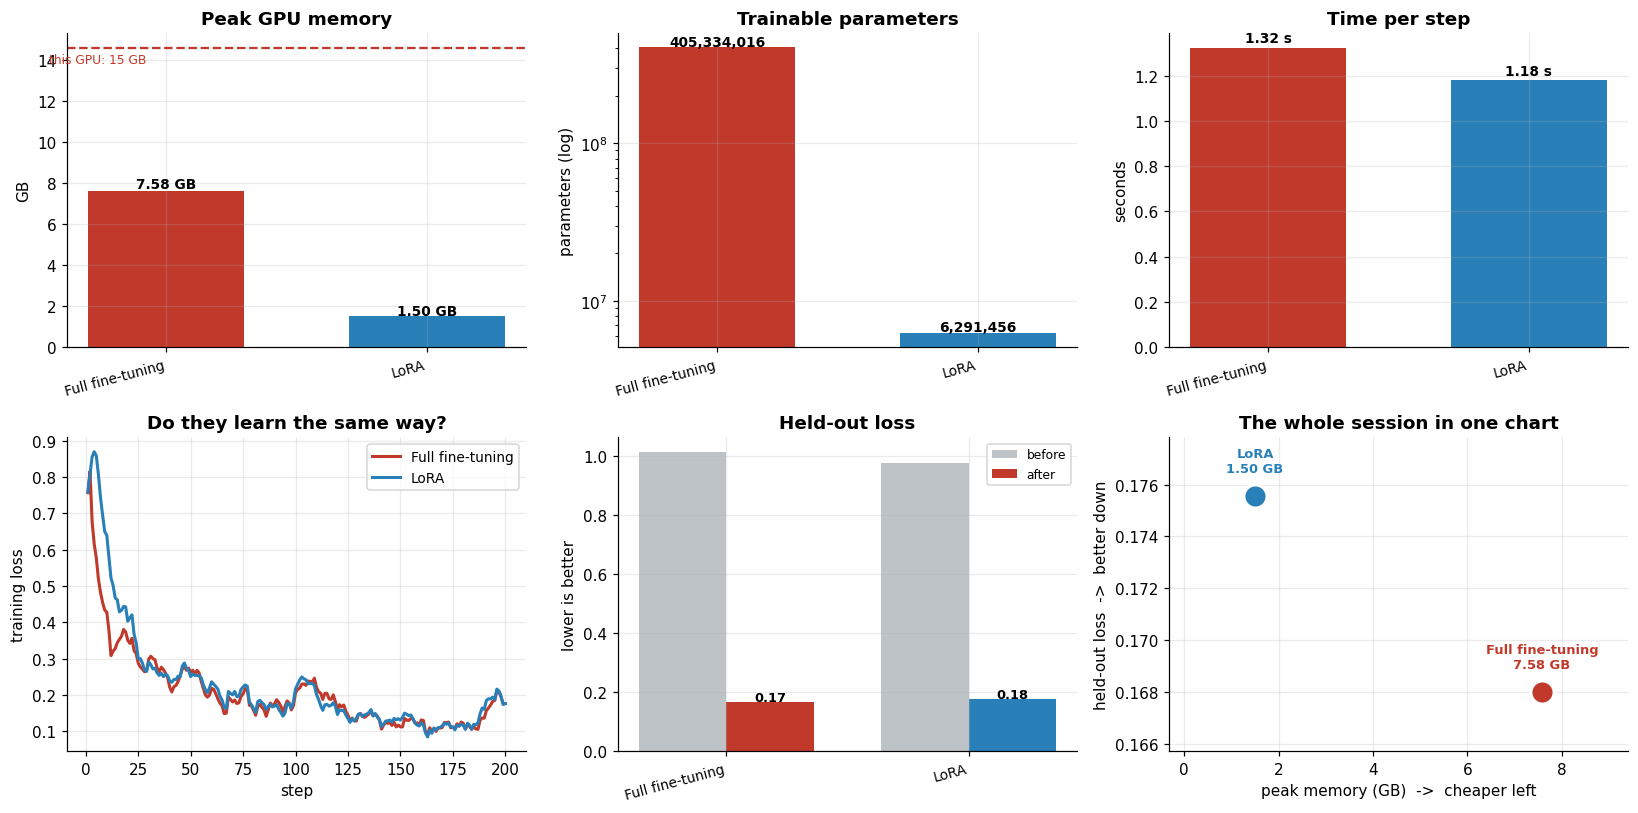

In [ ]:
def plot_comparison(results):
    ok = {k: v for k, v in results.items() if v.get("status") == "ok"}
    if not ok:
        print("no successful runs"); return
    names = list(ok); cols = [COLORS[n] for n in names]
    fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))

    def bar(a, vals, title, ylab, fmt="{:.2f}", log=False):
        b = a.bar(range(len(names)), vals, color=cols, width=.6)
        a.set_xticks(range(len(names))); a.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
        a.set_title(title); a.set_ylabel(ylab)
        if log:
            a.set_yscale("log")
        for bb, v in zip(b, vals):
            a.text(bb.get_x() + bb.get_width() / 2, v * 1.02, fmt.format(v),
                   ha="center", fontsize=9, fontweight="bold")

    bar(ax[0, 0], [ok[n]["peak_train_memory_gb"] for n in names],
        "Peak GPU memory", "GB", "{:.2f} GB")
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_properties(0).total_memory / GB
        ax[0, 0].axhline(cap, ls="--", color="#c0392b")
        ax[0, 0].text(-.45, cap * .95, f"this GPU: {cap:.0f} GB", fontsize=8, color="#c0392b")
    bar(ax[0, 1], [ok[n]["trainable"] for n in names], "Trainable parameters",
        "parameters (log)", "{:,.0f}", log=True)
    bar(ax[0, 2], [ok[n]["sec_per_step"] for n in names], "Time per step", "seconds", "{:.2f} s")

    for n in names:
        h = pd.DataFrame(ok[n]["history"])
        ax[1, 0].plot(h["step"], h["loss"].rolling(10, min_periods=1).mean(),
                      color=COLORS[n], lw=2, label=n)
    ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("training loss"); ax[1, 0].legend(fontsize=9)
    ax[1, 0].set_title("Do they learn the same way?")

    x, w = np.arange(len(names)), .36
    bef = [ok[n]["before"]["eval_loss"] for n in names]
    aft = [ok[n]["after"]["eval_loss"] for n in names]
    ax[1, 1].bar(x - w / 2, bef, w, color="#bdc3c7", label="before")
    ax[1, 1].bar(x + w / 2, aft, w, color=cols, label="after")
    for i, (b_, a_) in enumerate(zip(bef, aft)):
        ax[1, 1].text(i + w / 2, a_ * 1.02, f"{a_:.2f}", ha="center", fontsize=8.5, fontweight="bold")
    ax[1, 1].set_xticks(x); ax[1, 1].set_xticklabels(names, rotation=15, ha="right", fontsize=9)
    ax[1, 1].set_title("Held-out loss"); ax[1, 1].set_ylabel("lower is better"); ax[1, 1].legend(fontsize=8)

    for n in names:
        ax[1, 2].scatter(ok[n]["peak_train_memory_gb"], ok[n]["after"]["eval_loss"], s=230,
                         color=COLORS[n], edgecolor="white", linewidth=2, zorder=3)
        ax[1, 2].annotate(f"{n}\n{ok[n]['peak_train_memory_gb']:.2f} GB",
                          (ok[n]["peak_train_memory_gb"], ok[n]["after"]["eval_loss"]),
                          textcoords="offset points", xytext=(0, 16), ha="center",
                          fontsize=8.5, fontweight="bold", color=COLORS[n])
    ax[1, 2].set_xlabel("peak memory (GB)  ->  cheaper left")
    ax[1, 2].set_ylabel("held-out loss  ->  better down")
    ax[1, 2].set_title("The whole session in one chart")
    ax[1, 2].set_xmargin(.30); ax[1, 2].set_ymargin(.30)
    plt.tight_layout(); plt.show()


plot_comparison(RESULTS)

# Does the rank matter? Sweeping *r*

As $r$ grows, $BA$ can express higher-rank updates, and
at full rank LoRA *is* full fine-tuning. Small $r$ is a cheap approximation. So where is the
knee in practice?

We hold everything constant and vary only $r$ — including **$\alpha = 2r$, so the effective
scale $\alpha/r$ stays fixed at 2**. Otherwise we would be changing two things at once and the
plot would tell us nothing about rank.

In [ ]:
RANKS, SWEEP_STEPS, SWEEP_GEN = (1, 4, 16, 64), 60 if QUICK_MODE else 120, 24

sweep = {}
for r in RANKS:
    cfg = RunConfig(name=f"QLoRA r={r}", mode="qlora", lora_r=r, lora_alpha=2 * r,
                    lr=2e-4, max_steps=SWEEP_STEPS, optimizer="paged_adamw_8bit")
    sweep[r] = run_experiment(cfg, n_gen=SWEEP_GEN, eval_before=False, verbose=False)
    free_memory()

df_sweep = pd.DataFrame([{"rank r": r, "trainable params": s["trainable"],
                          "% trainable": s["trainable_pct"],
                          "peak memory (GB)": s["peak_train_memory_gb"],
                          "sec / step": s["sec_per_step"],
                          "eval loss": s["after"]["eval_loss"],
                          "exact match": s["after"]["exact_match"],
                          "token F1": s["after"]["token_f1"]}
                         for r, s in sweep.items() if s.get("status") == "ok"])
display(df_sweep.style.format({"trainable params": "{:,.0f}", "% trainable": "{:.2f} %",
                               "peak memory (GB)": "{:.2f}", "sec / step": "{:.2f}",
                               "eval loss": "{:.4f}", "exact match": "{:.3f}",
                               "token F1": "{:.3f}"}).hide(axis="index"))

EXPERIMENT: QLoRA r=1  (mode=qlora, r=1, lr=0.0002, steps=120)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  step    1/120  loss 1.2800  peak  0.86 GB
  step   15/120  loss 0.5479  peak  0.90 GB
  step   30/120  loss 0.4190  peak  0.90 GB
  step   45/120  loss 0.1979  peak  0.90 GB
  step   60/120  loss 0.3057  peak  0.98 GB
  step   75/120  loss 0.4462  peak  0.98 GB
  step   90/120  loss 0.1555  peak  0.98 GB
  step  105/120  loss 0.2214  peak  1.09 GB
  step  120/120  loss 0.2363  peak  1.14 GB
  AFTER   loss 0.3484 | EM 0.208 | F1 0.845 | peak 1.14 GB | 1.20 s/step
EXPERIMENT: QLoRA r=4  (mode=qlora, r=4, lr=0.0002, steps=120)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  step    1/120  loss 1.2800  peak  0.86 GB
  step   15/120  loss 0.2747  peak  0.91 GB
  step   30/120  loss 0.3023  peak  0.91 GB
  step   45/120  loss 0.1797  peak  0.91 GB
  step   60/120  loss 0.2631  peak  0.99 GB
  step   75/120  loss 0.4235  peak  0.99 GB
  step   90/120  loss 0.1015  peak  0.99 GB
  step  105/120  loss 0.2062  peak  1.10 GB
  step  120/120  loss 0.1586  peak  1.15 GB
  AFTER   loss 0.2796 | EM 0.333 | F1 0.894 | peak 1.15 GB | 1.30 s/step
EXPERIMENT: QLoRA r=16  (mode=qlora, r=16, lr=0.0002, steps=120)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  step    1/120  loss 1.2800  peak  0.90 GB
  step   15/120  loss 0.3152  peak  0.95 GB
  step   30/120  loss 0.2956  peak  0.95 GB
  step   45/120  loss 0.1262  peak  0.95 GB
  step   60/120  loss 0.1947  peak  1.03 GB
  step   75/120  loss 0.3521  peak  1.03 GB
  step   90/120  loss 0.0455  peak  1.03 GB
  step  105/120  loss 0.1592  peak  1.12 GB
  step  120/120  loss 0.1092  peak  1.19 GB
  AFTER   loss 0.2227 | EM 0.292 | F1 0.886 | peak 1.19 GB | 1.31 s/step
EXPERIMENT: QLoRA r=64  (mode=qlora, r=64, lr=0.0002, steps=120)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

  repaired output head from 'embed_out.weight'
  step    1/120  loss 1.2800  peak  1.04 GB
  step   15/120  loss 0.2165  peak  1.10 GB
  step   30/120  loss 0.2198  peak  1.10 GB
  step   45/120  loss 0.1465  peak  1.10 GB
  step   60/120  loss 0.1448  peak  1.18 GB
  step   75/120  loss 0.3416  peak  1.18 GB
  step   90/120  loss 0.0254  peak  1.18 GB
  step  105/120  loss 0.1211  peak  1.20 GB
  step  120/120  loss 0.0877  peak  1.34 GB
  AFTER   loss 0.1739 | EM 0.417 | F1 0.918 | peak 1.34 GB | 1.34 s/step


rank r,trainable params,% trainable,peak memory (GB),sec / step,eval loss,exact match,token F1
1,"393,216",0.10 %,1.14,1.20,0.3484,0.208,0.845
4,"1,572,864",0.39 %,1.15,1.30,0.2796,0.333,0.894
16,"6,291,456",1.53 %,1.19,1.31,0.2227,0.292,0.886
64,"25,165,824",5.85 %,1.34,1.34,0.1739,0.417,0.918


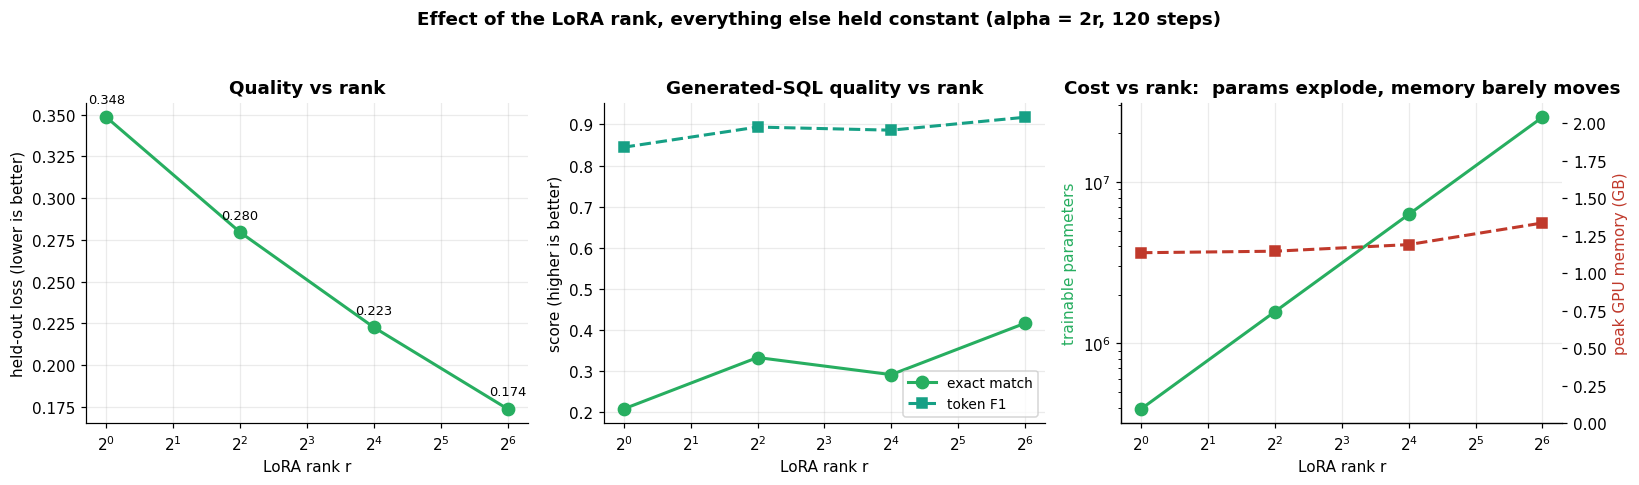

Best held-out loss at r = 64 (0.1739, 25,165,824 trainable params, 1.34 GB).
Going from r=1 to r=64 multiplies trainable parameters by 64x and changes peak memory by only +17.4 %.


In [ ]:
def plot_rank_sweep(df, sweep):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    G, R = COLORS["QLoRA"], COLORS["Full fine-tuning"]

    ax[0].plot(df["rank r"], df["eval loss"], "o-", color=G, lw=2, ms=8)
    for _, row in df.iterrows():
        ax[0].annotate(f"{row['eval loss']:.3f}", (row["rank r"], row["eval loss"]),
                       textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8.5)
    ax[0].set_xscale("log", base=2); ax[0].set_xlabel("LoRA rank r")
    ax[0].set_ylabel("held-out loss (lower is better)"); ax[0].set_title("Quality vs rank")

    ax[1].plot(df["rank r"], df["exact match"], "o-", color=G, lw=2, ms=8, label="exact match")
    ax[1].plot(df["rank r"], df["token F1"], "s--", color="#16a085", lw=2, ms=7, label="token F1")
    ax[1].set_xscale("log", base=2); ax[1].set_xlabel("LoRA rank r")
    ax[1].set_ylabel("score (higher is better)"); ax[1].set_title("Generated-SQL quality vs rank")
    ax[1].legend(fontsize=9)

    ax[2].plot(df["rank r"], df["trainable params"], "o-", color=G, lw=2, ms=8)
    ax[2].set_xscale("log", base=2); ax[2].set_yscale("log")
    ax[2].set_xlabel("LoRA rank r"); ax[2].set_ylabel("trainable parameters", color=G)
    a2 = ax[2].twinx(); a2.grid(False)
    a2.plot(df["rank r"], df["peak memory (GB)"], "s--", color=R, lw=2, ms=7)
    a2.set_ylabel("peak GPU memory (GB)", color=R)
    a2.set_ylim(0, max(df["peak memory (GB)"]) * 1.6)
    ax[2].set_title("Cost vs rank:  params explode, memory barely moves")

    plt.suptitle("Effect of the LoRA rank, everything else held constant "
                 f"(alpha = 2r, {SWEEP_STEPS} steps)", fontweight="bold", y=1.04)
    plt.tight_layout(); plt.show()

    best = df.loc[df["eval loss"].idxmin()]
    print(f"Best held-out loss at r = {int(best['rank r'])} "
          f"({best['eval loss']:.4f}, {best['trainable params']:,.0f} trainable params, "
          f"{best['peak memory (GB)']:.2f} GB).")
    lo, hi = df.iloc[0], df.iloc[-1]
    print(f"Going from r={int(lo['rank r'])} to r={int(hi['rank r'])} multiplies trainable "
          f"parameters by {hi['trainable params']/lo['trainable params']:.0f}x "
          f"and changes peak memory by only "
          f"{100*(hi['peak memory (GB)']/lo['peak memory (GB)']-1):+.1f} %.")


plot_rank_sweep(df_sweep, sweep)

**Reading the sweep.** Expect quality to improve steeply from $r{=}1$ to about $r{=}8{-}16$
and then flatten: once the adapter has enough directions to express the update this task needs,
extra rank adds parameters without adding skill. Meanwhile the cost curve is almost flat —
peak memory barely moves, because the adapters were never the expensive part; the frozen base
and the activations are.

That asymmetry is the practical advice: **start at $r=16$, and if quality is short, raise the
rank before you reach for a bigger GPU.** Very low ranks ($r \le 2$) genuinely lose capacity,
and very high ranks mostly waste it.

# <font color="blue"><b>Section-8. Concluding Remarks, Future Direction and Important References </b></font>

### Things to try next

| Change | | What you should see |
|---|---|---|
| `MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"` |  | full fine-tuning OOMs; QLoRA does not |
| `bnb_4bit_use_double_quant=False` |  | +0.37 bits/param, identical quality |
| `bnb_4bit_quant_type="fp4"` |  | slightly worse — that is why NF4 is the default |
| `gradient_checkpointing=False` |  | faster steps, higher peak memory |
| adapt attention only, in `find_lora_targets` |  | fewer parameters, usually a little worse |
| `merge_lora_` on every `LoRALinear`, then save |  | one standalone model, zero inference overhead |

### Extra Resouces:

1. If you want to do finetuing using peft library only: https://colab.research.google.com/drive/1Dnj1pbYL2k7ckZ3Xa1ktpOq42jcKB5Bt#scrollTo=DwLC_-Kr5F47

2. Basic understanding of LoRA:

    a. https://lightning.ai/lightning-ai/templates/code-lora-from-scratch?section=featured&tab=overview
  
    b. https://github.com/huggingface/trl/blob/main/examples/notebooks/sft_trl_lora_qlora.ipynb


### References

1. Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
2. Dettmers et al. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs.* NeurIPS. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
3. Dettmers & Zettlemoyer (2023). *The case for 4-bit precision.* ICML. [arXiv:2212.09720](https://arxiv.org/abs/2212.09720)
4. Chen et al. (2016). *Training Deep Nets with Sublinear Memory Cost.* [arXiv:1604.06174](https://arxiv.org/abs/1604.06174) — gradient checkpointing
5. Biderman et al. (2023). *Pythia.* ICML. [arXiv:2304.01373](https://arxiv.org/abs/2304.01373) — the model used here (Apache 2.0)
6. `b-mc2/sql-create-context` (CC BY-4.0), from WikiSQL (BSD-3) and Spider (CC BY-SA-4.0)
7. `bitsandbytes` (MIT) · Hugging Face `peft` (Apache 2.0).


---
<div align="center"><em>End of demo</em></div>